# JWST MIRI False-Color Composite of M42

This notebook builds an RGB false-color image from three JWST MIRI imaging filters of the Orion Nebula (M42), observed as part of the PDRs4All Early Release Science program (PID 1288).

**Filter-to-channel mapping** (standard infrared convention — longer wavelength → redder color):

| Channel | Filter | Wavelength |
|---------|--------|------------|
| Blue    | F770W  | 7.7 µm    |
| Green   | F1500W | 15.0 µm   |
| Red     | F2550W | 25.5 µm   |

In [ ]:
from astropy.io import fits 
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np
import os
import re
import glob
import json

# Read target and filters from the config saved by Working_draft.ipynb
with open("target_config.json") as cfg:
    config = json.load(cfg)
target_name = config["target_name"]
target_filters = config["target_filters"]
print(f"Target: {target_name}, Filters: {target_filters}")

fits_dir = f"./fits_images/{target_name}" #builds the path to the folder where the fits files live

# Auto-discover FITS files by scanning the target folder and matching filter names
fits_files = {}
for fpath in sorted(glob.glob(os.path.join(fits_dir, "*_i2d.fits"))):
    fname = os.path.basename(fpath).lower()
    m = re.search(r"_f(\d+w)", fname)
    if m:
        detected_filter = f"F{m.group(1).upper()}"
        if detected_filter in target_filters:
            fits_files[detected_filter] = fpath

for f in target_filters:
    if f in fits_files:
        print(f"  {f}: OK  ({fits_files[f]})")
    else:
        print(f"  WARNING: {f}: MISSING — no matching file found in {fits_dir}")

missing = [f for f in target_filters if f not in fits_files]
if missing:
    print(f"\n  Filters requested but missing: {missing}")

target_filters = [f for f in target_filters if f in fits_files]
n_bands = len(target_filters)
if n_bands == 0:
    raise SystemExit(f"ERROR: No matching FITS files found in {fits_dir}")
elif n_bands < 3:
    print(f"\n  Only {n_bands} filter(s) found — will display accordingly.")

Target: M104, Filters: ['F770W', 'F1500W', 'F2550W']
  F770W: OK  (./fits_images/M104/jw06565-o001_t001_miri_f770w_i2d.fits)

  Filters requested but missing: ['F1500W', 'F2550W']

  Only 1 filter(s) found — will display accordingly.


## Load, Clean, and Align the Three Bands

1. **Pandas DataFrame** — organizes the filters by wavelength and assigns each to an RGB channel.
2. **FITS loading** — reads the 2-D science image from each `_i2d.fits` file.
3. **NaN filling** — replaces missing-coverage pixels (from incomplete dither overlap) with the nearest valid pixel value.
4. **North-up reprojection** — the MIRI detector was rotated ~87° on the sky; all bands are reprojected onto a common North-up, East-left WCS grid so the image appears upright.

In [ ]:
import pandas as pd
from reproject import reproject_interp

# --- Build a pandas DataFrame of our three bands ---
rows = []
for f in target_filters: #creating the pandas data frame
    path = fits_files[f]
    rows.append({
        "filter": f,
        "wavelength_um": float(f.replace("F", "").replace("W", "")) / 100, #wavelength
        "filename": os.path.basename(path), #name of the new file
        "path": path,
    })

bands_df = pd.DataFrame(rows).sort_values("wavelength_um").reset_index(drop=True) #sorting the data by wavelength now
n_bands = len(bands_df) 
if n_bands == 3: #if there are 3 bands, we have our full false color image with each color of the RGB fulfilled 
    bands_df["rgb_channel"] = ["B", "G", "R"]
elif n_bands == 2: #if there are 2 bands, we will display a false color image with the blue and red channels
    bands_df["rgb_channel"] = ["B", "R"]  # shortest→blue, longest→red, green=average
    print("  2 filters: green channel will be synthesized as average of the two.")
elif n_bands == 1: #if there is only one band, we will display a single band image with a colormap
    bands_df["rgb_channel"] = ["mono"]
    print("  1 filter: will display as single-band image with colormap.")
print(bands_df.to_string(index=False))

# --- Load each band's 2-D image and its WCS ---
images, headers = {}, {} #this is a dictionary that will store the images and headers for each band
for _, row in bands_df.iterrows():
    hdul = fits.open(row["path"])
    ext = "SCI" if "SCI" in [h.name for h in hdul] else 1
    data = np.squeeze(hdul[ext].data)
    if data.ndim == 3:
        data = np.nansum(data, axis=0)
    images[row["filter"]] = data
    headers[row["filter"]] = hdul[ext].header
    hdul.close()

bands_df["shape"] = [images[f].shape for f in bands_df["filter"]] #list of shapes of the images for each band
print("\nLoaded shapes:")
print(bands_df[["filter", "rgb_channel", "shape"]].to_string(index=False))

# --- Fill NaN gaps via nearest-neighbor interpolation ---
from scipy.ndimage import distance_transform_edt #this feature is very important, it is what fills in the NaN values in the image so there are not as many gaps and ugly pixels

def fill_nans(data):
    """Replace NaN pixels with the nearest valid pixel value."""
    mask = np.isnan(data) #mask is a boolean array that is True for NaN values and False otherwise
    if not mask.any():
        return data
    ind = distance_transform_edt(mask, return_distances=False, return_indices=True) #this is the function that fills in the NaN values
    return data[tuple(ind)]

for f in images: #this is a for loop that fills in the NaN values in the image
    before = np.isnan(images[f]).sum()
    images[f] = fill_nans(images[f])
    print(f"  {f}: filled {before} NaN pixels")

# --- Build a North-up WCS so the image isn't rotated ---
ref_filter = bands_df.iloc[0]["filter"] #this is the reference filter, which is the first one in the list
orig_wcs = WCS(headers[ref_filter], naxis=2)
ny, nx = images[ref_filter].shape

# Pixel scale from the original WCS (degrees/pixel)
pixscale = np.sqrt(np.abs(np.linalg.det(orig_wcs.wcs.pc))) * np.abs(orig_wcs.wcs.cdelt[0])

# Sky center of the original image
center_sky = orig_wcs.pixel_to_world(nx / 2, ny / 2)

# Pad output a bit so no corners are clipped after rotation
diag = int(np.ceil(np.sqrt(nx**2 + ny**2)))
out_ny, out_nx = diag, diag

#setting up the new WCS so that the image is oriented correctly 
ref_wcs = WCS(naxis=2) 
ref_wcs.wcs.crpix = [out_nx / 2, out_ny / 2]
ref_wcs.wcs.crval = [center_sky.ra.deg, center_sky.dec.deg]
ref_wcs.wcs.cdelt = [-pixscale, pixscale]   # North up, East left
ref_wcs.wcs.pc = [[1, 0], [0, 1]]           # no rotation
ref_wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
ref_shape = (out_ny, out_nx)

# --- Reproject all bands onto the North-up grid ---
aligned = {}
for _, row in bands_df.iterrows():
    f = row["filter"]
    src_wcs = WCS(headers[f], naxis=2)
    reprojected, footprint = reproject_interp(
        (images[f], src_wcs), ref_wcs, shape_out=ref_shape
    )
    reprojected[~np.isfinite(reprojected)] = 0
    aligned[f] = reprojected

print(f"\nAll bands reprojected to North-up grid ({ref_shape[0]}×{ref_shape[1]} px)")

  1 filter: will display as single-band image with colormap.
filter  wavelength_um                              filename                                                     path rgb_channel
 F770W            7.7 jw06565-o001_t001_miri_f770w_i2d.fits ./fits_images/M104/jw06565-o001_t001_miri_f770w_i2d.fits        mono

Loaded shapes:
filter rgb_channel        shape
 F770W        mono (3917, 2247)
  F770W: filled 2745393 NaN pixels


Set OBSGEO-B to   -34.774475 from OBSGEO-[XYZ].
Set OBSGEO-H to 1719261867.058 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -34.774475 from OBSGEO-[XYZ].
Set OBSGEO-H to 1719261867.058 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]



All bands reprojected to North-up grid (4516×4516 px)


## What Happened Above

After running the cell above, every filter's image has been:

1. **Organized** into a pandas DataFrame sorted by wavelength — shortest wavelength (F770W, 7.7 µm) assigned to Blue, middle (F1500W, 15.0 µm) to Green, longest (F2550W, 25.5 µm) to Red.
2. **Loaded** from its FITS file — the raw pixel data is a 2-D NumPy array where each value is the flux (brightness) at that pixel.
3. **Cleaned** — NaN pixels (gaps in the mosaic from incomplete dither overlap) were filled by copying the nearest valid pixel's value using a Euclidean distance transform.
4. **Reprojected** — all bands were mapped onto a new coordinate grid that is:
   - **North-up** — Declination increases straight upward, RA increases to the left
   - **Common** — all three filters share the exact same pixel grid, so pixel (100, 200) in one band corresponds to the same sky position in every other band
   - **Unrotated** — the identity PC matrix `[[1,0],[0,1]]` removes the physical detector rotation (~87° for M42)

The `aligned` dictionary now holds three 2-D arrays of identical shape, ready to be combined into RGB channels.

## Stretch, Enhance, and Display

- **Gaussian smoothing** (σ = 0.8 px) reduces single-pixel noise before the nonlinear stretch.
- **Arcsinh stretch** compresses the large dynamic range so both bright stars and faint nebulosity are visible.
- **Saturation boost** amplifies color differences between channels for a more vivid composite.
- The final image is **cropped** to the overlap region of all three bands and displayed on a dark background.

### Crop to Overlap, Adjust WCS, and Plot

After the RGB (or mono) image is assembled, the code below does three more things before displaying:

**Cropping** — The reprojected canvas is deliberately oversized (diagonal of the original image) to prevent clipping. Most of that extra space is black (zero). The crop logic finds the tightest bounding box that contains all non-zero pixels:
- `np.any(rgb > 0, axis=-1)` creates a 2-D boolean mask: `True` wherever *any* of the R, G, or B channels is non-zero
- `np.where(any_data.any(axis=1))` finds which *rows* contain at least one `True` — the first and last of these define the vertical crop bounds
- Same logic on `axis=0` for columns (horizontal bounds)
- The image is then sliced to that bounding box, removing all the surrounding black

**WCS adjustment** — Cropping removes rows and columns from the top-left corner of the array, which shifts where the reference pixel sits. `crop_wcs.wcs.crpix[0] -= crop_origin[1]` subtracts the number of columns removed (shifting the RA reference), and `crpix[1] -= crop_origin[0]` subtracts rows removed (shifting the Dec reference). Without this correction, the RA/Dec axis labels would be wrong after cropping.

**Figure sizing** — `fig_h = fig_w * ny / nx + 1.4` scales the figure height to match the image's aspect ratio, plus 1.4 inches of padding for the title and axis labels. The `max(..., 6)` ensures the figure is never too small.

**Plotting** — `projection=crop_wcs` tells matplotlib to use the corrected WCS for axis labels, so tick marks show RA and Dec instead of pixel numbers. For multi-band images, `imshow` displays the RGB array directly. For single-band images, it uses the `inferno` colormap with a colorbar. The final image is saved at 300 DPI on a black background.

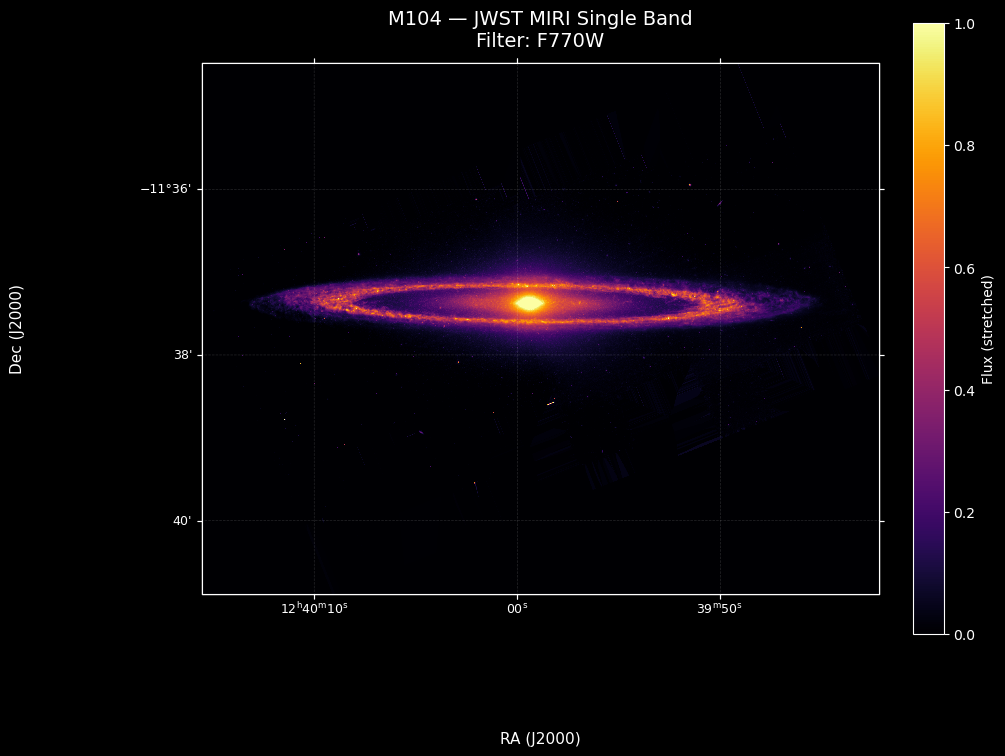

Saved M104_false_color.png (300 DPI)


In [ ]:
from scipy.ndimage import gaussian_filter

#in astronomy, there is often a background that is not the object we are observing, this is a function that subtracts the background from the image so it does not dominate the object
def subtract_background(img):
    """Subtract the median background so thermal pedestal doesn't dominate."""
    valid = img[img > 0]
    if len(valid) == 0:
        return img
    bg = np.median(valid)
    return np.clip(img - bg, 0, None)

#the stretch function serves to decrease the dynamic range of the image so that the bright is not so bright and the dark is not so dark, this is important so there is not a bunch of bright white
#or black meaningless pizels, arcsinh is better than log because it is less sensitive to outliers 
def stretch(img, lo=0.5, hi=99.8, gain=5):
    """Background-subtract, then arcsinh stretch normalized to 0-1."""
    img = np.nan_to_num(img, nan=0.0)
    img = subtract_background(img)
    pos = img[img > 0]
    if len(pos) == 0:
        return np.zeros_like(img)
    vmin = np.percentile(pos, lo)
    vmax = np.percentile(pos, hi)
    normed = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return np.arcsinh(normed * gain) / np.arcsinh(gain)

#boost saturation works by increasing the contrast of the image so the colors are more vivid, preserving the luminance but not affecting the brightness 
def boost_saturation(rgb, factor=1.4):
    """Boost color saturation while preserving luminance."""
    lum = 0.2126 * rgb[:,:,0] + 0.7152 * rgb[:,:,1] + 0.0722 * rgb[:,:,2] 
    boosted = np.empty_like(rgb)
    for i in range(3):
        boosted[:,:,i] = lum + factor * (rgb[:,:,i] - lum)
    return np.clip(boosted, 0, 1)

channel_map = bands_df.set_index("rgb_channel")["filter"] #mapping the rgb channels to the filters
sigma = 0.8 #standard deviation of the gaussian filter to control the smoothing
n_bands = len(bands_df) #number of bands in the range of the image

#guassian filter is a type of low pass filter that is used to remove high frequency noise from the image
if n_bands == 3:
    r = stretch(gaussian_filter(aligned[channel_map["R"]], sigma=sigma)) #for each of the three bannds the stretch function is applied to the gaussian filter
    g = stretch(gaussian_filter(aligned[channel_map["G"]], sigma=sigma)) #each of the three bands is stretched by the arcsinh function and then the noise is removed by the gaussian filter
    b = stretch(gaussian_filter(aligned[channel_map["B"]], sigma=sigma))
    rgb = np.stack([r, g, b], axis=-1) #stacking the three bands together to form the false color image
    rgb = boost_saturation(rgb, factor=1.5) #boosting the saturation of the image
    subtitle = f"R = {channel_map['R']}   G = {channel_map['G']}   B = {channel_map['B']}" 

#this is the same logic, just if there are only two bands, the green channel is synthesized as the average of the two bands
elif n_bands == 2:
    r = stretch(gaussian_filter(aligned[channel_map["R"]], sigma=sigma))
    b = stretch(gaussian_filter(aligned[channel_map["B"]], sigma=sigma))
    g = (r + b) / 2
    rgb = np.stack([r, g, b], axis=-1)
    rgb = boost_saturation(rgb, factor=1.5)
    subtitle = f"R = {channel_map['R']}   G = synthetic   B = {channel_map['B']}"

#once again, the same logic, just if there is only one band, the image is displayed as a single band image with a colormap
else:
    mono = stretch(gaussian_filter(aligned[channel_map["mono"]], sigma=sigma))
    rgb = None
    subtitle = f"Filter: {channel_map['mono']}"


if rgb is not None:
    any_data = np.any(rgb > 0, axis=-1)
    rows_any = np.where(any_data.any(axis=1))[0]
    cols_any = np.where(any_data.any(axis=0))[0]
    if len(rows_any) > 0 and len(cols_any) > 0:
        crop_origin = (rows_any[0], cols_any[0])
        rgb = rgb[rows_any[0]:rows_any[-1]+1, cols_any[0]:cols_any[-1]+1]
    else:
        crop_origin = (0, 0)
    display_img = rgb
    ny, nx = rgb.shape[:2]
else:
    rows_any = np.where((mono > 0).any(axis=1))[0]
    cols_any = np.where((mono > 0).any(axis=0))[0]
    if len(rows_any) > 0 and len(cols_any) > 0:
        crop_origin = (rows_any[0], cols_any[0])
        mono = mono[rows_any[0]:rows_any[-1]+1, cols_any[0]:cols_any[-1]+1]
    else:
        crop_origin = (0, 0)
    display_img = mono
    ny, nx = mono.shape

# Shift WCS to match cropped region
crop_wcs = ref_wcs.deepcopy()
crop_wcs.wcs.crpix[0] -= crop_origin[1]
crop_wcs.wcs.crpix[1] -= crop_origin[0]

fig_w = 10
fig_h = max(fig_w * ny / nx + 1.4, 6)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(fig_w, fig_h),
                           subplot_kw={"projection": crop_wcs},
                           constrained_layout=True)
    if rgb is not None:
        ax.imshow(display_img, origin="lower", interpolation="nearest")
    else:
        im = ax.imshow(display_img, origin="lower", interpolation="nearest",
                       cmap="inferno")
        plt.colorbar(im, ax=ax, label="Flux (stretched)", shrink=0.8)
    ax.set_xlabel("RA (J2000)", fontsize=11, labelpad=8)
    ax.set_ylabel("Dec (J2000)", fontsize=11, labelpad=8)
    ax.coords.grid(color="white", alpha=0.15, ls="--", lw=0.5)
    mode_label = "False Color" if n_bands >= 2 else "Single Band"
    ax.set_title(
        f"{target_name} — JWST MIRI {mode_label}\n{subtitle}",
        fontsize=14, pad=12, color="white",
    )
    ax.tick_params(colors="white", labelsize=9)
    fig.savefig(
        f"{target_name}_false_color.png",
        dpi=300, bbox_inches="tight", facecolor="black", pad_inches=0.08,
    )
    plt.show()

print(f"Saved {target_name}_false_color.png (300 DPI)")
